Problem 1: Modified AlexNet on CIFAR-10

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import torch
print(torch.cuda.is_available())

True


In [ ]:
%load_ext tensorboard

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from torchsummary import summary
from sklearn.metrics import confusion_matrix
import seaborn as sns
import pandas as pd
import urllib.request
import time

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
#Seeds
torch.manual_seed(42)
np.random.seed(42)

In [ ]:
#Parameters
BATCH_SIZE = 64
EPOCHS = 50
lr = 0.001
img_height = 32

In [ ]:
#Load Data
my_path = '/content/drive/MyDrive/Intro_to_Deep_Learning/data/'

transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])
trainset = torchvision.datasets.CIFAR10(root=my_path, train=True, download=False, transform=transform_train)

# Creating a validation split (e.g., 40k train, 10k val)
train_size = int(0.8 * len(trainset))
val_size = len(trainset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(trainset, [train_size, val_size])

trainloader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
valloader = torch.utils.data.DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

testset = torchvision.datasets.CIFAR10(root=my_path, train=False, download=True, transform=transform_test)
testloader = torch.utils.data.DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

In [ ]:
"""
Functions:
Train and Evaluate
Plot Metrics
Visualize First Layer Filters
Plot Confusion Matrix
"""

def train_and_evaluate(model, criterion, optimizer, scheduler, num_epochs=30):
    train_losses, val_losses = [], []
    val_accuracies = []
    epoch_times = [] # Keep track of time per epoch

    for epoch in range(num_epochs):

        start_time = time.time()
        # --- Training Phase ---
        model.train()
        running_loss = 0.0
        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        epoch_train_loss = running_loss / len(trainloader)
        train_losses.append(epoch_train_loss)

        # --- Validation Phase ---
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, labels in valloader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        epoch_val_loss = val_loss / len(valloader)
        epoch_val_acc = 100 * correct / total

        val_losses.append(epoch_val_loss)
        val_accuracies.append(epoch_val_acc)

        # Step the scheduler
        if scheduler:
            scheduler.step()

        end_time = time.time()
        epoch_duration = end_time - start_time
        epoch_times.append(epoch_duration)

        print(f"Epoch [{epoch+1}/{num_epochs}] | Time: {epoch_duration:.2f}s | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.2f}%")

    return train_losses, val_losses, val_accuracies, epoch_times

def plot_metrics(train_losses, val_losses, val_accuracies, title="Model"):
    fig, ax1 = plt.subplots(figsize=(10, 5))

    ax1.plot(train_losses, label='Train Loss', color='blue')
    ax1.plot(val_losses, label='Val Loss', color='orange')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend(loc='upper left')

    ax2 = ax1.twinx()
    ax2.plot(val_accuracies, label='Val Accuracy', color='green', linestyle='dashed')
    ax2.set_ylabel('Accuracy (%)')
    ax2.legend(loc='upper right')

    plt.title(f'{title} - Training Metrics')
    plt.grid(True)
    plt.show()

def visualize_first_layer_filters(model):
    """
    https://www.geeksforgeeks.org/deep-learning/visualizing-feature-maps-using-pytorch/
    """
    first_conv_layer = None
    for module in model.modules():
        if isinstance(module, nn.Conv2d):
            first_conv_layer = module
            break

    if first_conv_layer is None:
        print("No convolutional layer found in the model.")
        return

    # Extract the weights (filters)
    weights = first_conv_layer.weight.data.cpu()

    #Normalize the weights for matplotlib
    w_min, w_max = weights.min(), weights.max()
    weights = (weights - w_min) / (w_max - w_min)

    #Set up the matplotlib grid (plot up to 64 filters)
    num_filters = min(64, weights.size(0))
    fig, axes = plt.subplots(8, 8, figsize=(10, 10))
    fig.suptitle('First Convolutional Layer Filters', fontsize=16)

    for i, ax in enumerate(axes.flat):
        if i < num_filters:
            # Reorder dimensions
            filter_img = weights[i].permute(1, 2, 0).numpy()
            ax.imshow(filter_img)
            ax.axis('off')
        else:
            ax.axis('off') # Hide any extra subplots if filters < 64

    plt.tight_layout()
    plt.show()

def plot_confusion_matrix(model, dataloader, class_names, device):

    model.eval()
    all_preds = []
    all_labels = []

    # Run inference to gather predictions and true labels
    print("Generating predictions for confusion matrix...")
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)

            # Get the index of the highest probability
            _, preds = torch.max(outputs, 1)

            # Move data back to CPU and append to lists
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # 2. Calculate the confusion matrix
    cm = confusion_matrix(all_labels, all_preds)

    # 3. Plot using Seaborn
    plt.figure(figsize=(10, 8))
    # Convert to DataFrame for automatic axis labeling
    df_cm = pd.DataFrame(cm, index=class_names, columns=class_names)

    sns.heatmap(df_cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title('CIFAR-10 Confusion Matrix', fontsize=16)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.show()

AlexNet Model Part 1

In [ ]:
# AlexNet model Part 1
class ModAlexNet(nn.Module):
    def __init__(self, num_classes=10, dropout_rate=0.0):
        super().__init__()
        self.features = nn.Sequential(
            # Conv1: Reduce the kernal size to more typical 5x5, reduce stride to 2, half the number of output filters
            nn.Conv2d(3, 48, kernel_size=3, stride=1, padding=0),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=1),

            # Conv2
            nn.Conv2d(48, 96, kernel_size=3, stride=1, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),

            # Conv3
            nn.Conv2d(96, 192, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),

            # Conv5
            nn.Conv2d(192, 146, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2)
        )

        # 2. Classifier (Dense/Linear Layers)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            # Assuming standard AlexNet input image size of 227x227
            # After pooling, spatial dimensions are 6x6.
            # 146 channels * 6 * 6 = 3650
            nn.Linear(146 * 6 * 6, 1825),
            nn.ReLU(inplace=True),

            nn.Linear(1825, 500),
            nn.ReLU(inplace=True),

            # Output layer (No Softmax here!)
            nn.Linear(500, num_classes)
        )

        # 3. Apply He Normal (Kaiming) Initialization
        self._initialize_weights()

    # 4. Explicitly define the forward pass
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.constant_(m.bias, 0)

# Instantiate and check parameter count
alexnet = ModAlexNet(dropout_rate=0.0).to(device)
summary(alexnet, (3, 32, 32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 48, 30, 30]           1,344
              ReLU-2           [-1, 48, 30, 30]               0
         MaxPool2d-3           [-1, 48, 28, 28]               0
            Conv2d-4           [-1, 96, 30, 30]          41,568
              ReLU-5           [-1, 96, 30, 30]               0
         MaxPool2d-6           [-1, 96, 14, 14]               0
            Conv2d-7          [-1, 192, 14, 14]         166,080
              ReLU-8          [-1, 192, 14, 14]               0
            Conv2d-9          [-1, 146, 14, 14]         252,434
             ReLU-10          [-1, 146, 14, 14]               0
        MaxPool2d-11            [-1, 146, 6, 6]               0
          Flatten-12                 [-1, 5256]               0
           Linear-13                 [-1, 1825]       9,594,025
             ReLU-14                 [-

Epoch [1/50] | Time: 10.92s | Train Loss: 1.6267 | Val Loss: 1.2961 | Val Acc: 52.91%
Epoch [2/50] | Time: 10.62s | Train Loss: 1.1920 | Val Loss: 1.0668 | Val Acc: 62.38%
Epoch [3/50] | Time: 10.58s | Train Loss: 0.9930 | Val Loss: 0.9376 | Val Acc: 67.50%
Epoch [4/50] | Time: 10.63s | Train Loss: 0.8872 | Val Loss: 0.8354 | Val Acc: 71.00%
Epoch [5/50] | Time: 10.37s | Train Loss: 0.8048 | Val Loss: 0.7954 | Val Acc: 72.47%
Epoch [6/50] | Time: 10.85s | Train Loss: 0.7349 | Val Loss: 0.8102 | Val Acc: 71.46%
Epoch [7/50] | Time: 11.21s | Train Loss: 0.6871 | Val Loss: 0.7328 | Val Acc: 74.87%
Epoch [8/50] | Time: 10.89s | Train Loss: 0.6534 | Val Loss: 0.6879 | Val Acc: 76.11%
Epoch [9/50] | Time: 10.67s | Train Loss: 0.6198 | Val Loss: 0.7261 | Val Acc: 75.23%
Epoch [10/50] | Time: 10.75s | Train Loss: 0.5894 | Val Loss: 0.6756 | Val Acc: 76.73%
Epoch [11/50] | Time: 10.74s | Train Loss: 0.4555 | Val Loss: 0.5895 | Val Acc: 79.96%
Epoch [12/50] | Time: 10.75s | Train Loss: 0.4223 | 

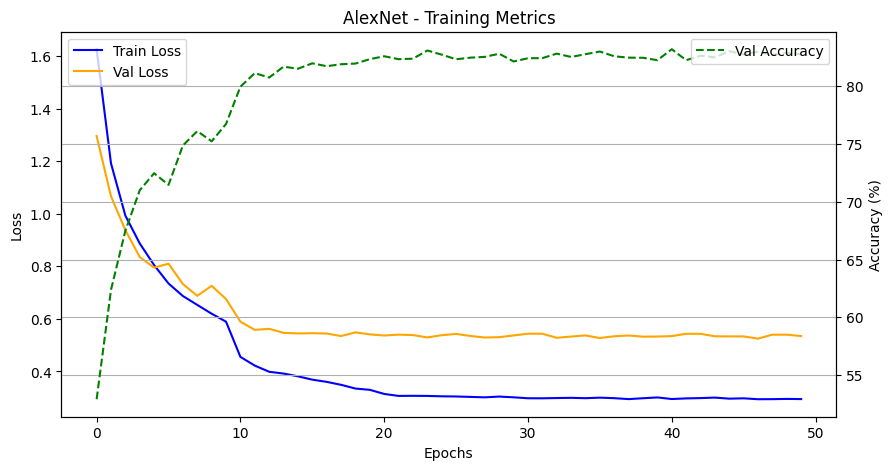

In [ ]:
# In PyTorch, compilation happens outside the model
optimizer = torch.optim.Adam(alexnet.parameters(), lr=lr)

# CrossEntropyLoss automatically applies Softmax internally!
criterion = nn.CrossEntropyLoss()
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)
train_losses, val_losses, val_accuracies, epoch_times = train_and_evaluate(alexnet, criterion=criterion, optimizer=optimizer,scheduler=scheduler, num_epochs=EPOCHS)
Average_Time = sum(epoch_times) / len(epoch_times)
print(f"Average time per epoch: {Average_Time:.2f} seconds")
plot_metrics(train_losses, val_losses, val_accuracies, title="AlexNet")

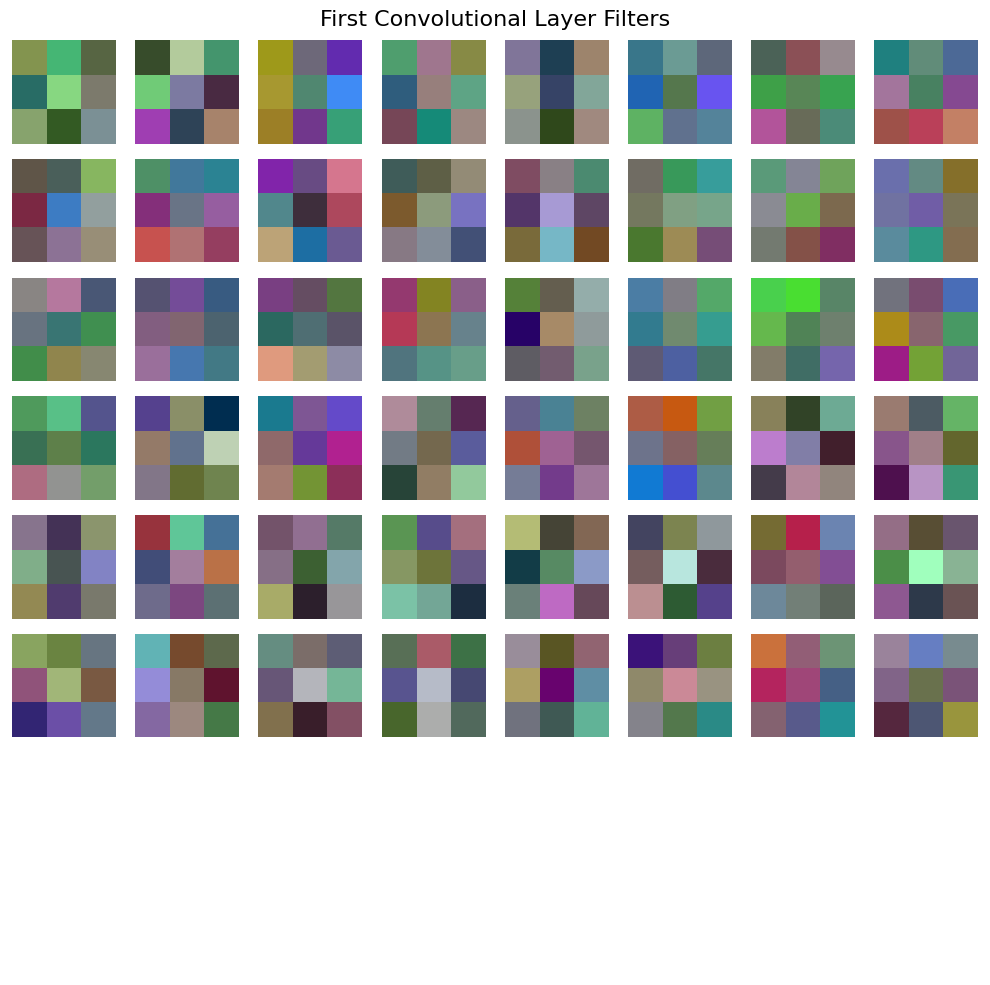

Generating predictions for confusion matrix...


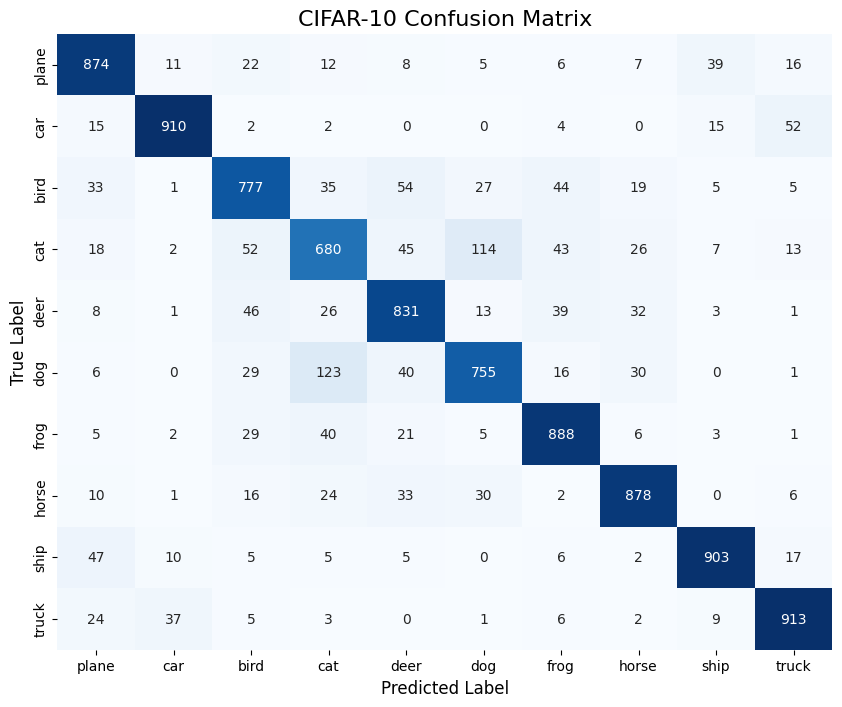

In [ ]:
visualize_first_layer_filters(alexnet)
plot_confusion_matrix(alexnet, testloader, classes, device)

In [ ]:
torch.save(alexnet.state_dict(), '/content/drive/MyDrive/alexnet_cifar10.pth')

AlexNet Part B: Dropout

In [ ]:
# AlexNet model Part 2
class ModAlexNetD(nn.Module):
    def __init__(self, num_classes=10, dropout_rate=0.0):
        super().__init__()
        self.features = nn.Sequential(
            # Conv1: Reduce the kernal size to more typical 5x5, reduce stride to 2, half the number of output filters
            nn.Conv2d(3, 48, kernel_size=3, stride=1, padding=0),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=1),

            # Conv2
            nn.Conv2d(48, 96, kernel_size=3, stride=1, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),

            # Conv3
            nn.Conv2d(96, 192, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),

            # Conv5
            nn.Conv2d(192, 146, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2)
        )

        # 2. Classifier (Dense/Linear Layers)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            # Assuming standard AlexNet input image size of 227x227
            # After pooling, spatial dimensions are 6x6.
            # 146 channels * 6 * 6 = 3650
            nn.Linear(146 * 6 * 6, 1825),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_rate),

            nn.Linear(1825, 500),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_rate),

            # Output layer (No Softmax here!)
            nn.Linear(500, num_classes)
        )

        # 3. Apply He Normal (Kaiming) Initialization
        self._initialize_weights()

    # 4. Explicitly define the forward pass
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.constant_(m.bias, 0)

# Instantiate and check parameter count
alexnet3 = ModAlexNetD(dropout_rate=0.3).to(device)
summary(alexnet3, (3, 32, 32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 48, 30, 30]           1,344
              ReLU-2           [-1, 48, 30, 30]               0
         MaxPool2d-3           [-1, 48, 28, 28]               0
            Conv2d-4           [-1, 96, 30, 30]          41,568
              ReLU-5           [-1, 96, 30, 30]               0
         MaxPool2d-6           [-1, 96, 14, 14]               0
            Conv2d-7          [-1, 192, 14, 14]         166,080
              ReLU-8          [-1, 192, 14, 14]               0
            Conv2d-9          [-1, 146, 14, 14]         252,434
             ReLU-10          [-1, 146, 14, 14]               0
        MaxPool2d-11            [-1, 146, 6, 6]               0
          Flatten-12                 [-1, 5256]               0
           Linear-13                 [-1, 1825]       9,594,025
             ReLU-14                 [-

Epoch [1/50] | Time: 11.23s | Train Loss: 1.6937 | Val Loss: 1.3776 | Val Acc: 49.64%
Epoch [2/50] | Time: 10.85s | Train Loss: 1.2645 | Val Loss: 1.1002 | Val Acc: 60.80%
Epoch [3/50] | Time: 10.43s | Train Loss: 1.0709 | Val Loss: 0.9487 | Val Acc: 65.88%
Epoch [4/50] | Time: 10.96s | Train Loss: 0.9500 | Val Loss: 0.8628 | Val Acc: 69.70%
Epoch [5/50] | Time: 10.71s | Train Loss: 0.8773 | Val Loss: 0.8614 | Val Acc: 70.19%
Epoch [6/50] | Time: 11.25s | Train Loss: 0.8173 | Val Loss: 0.7627 | Val Acc: 73.66%
Epoch [7/50] | Time: 10.77s | Train Loss: 0.7794 | Val Loss: 0.7885 | Val Acc: 72.93%
Epoch [8/50] | Time: 11.24s | Train Loss: 0.7447 | Val Loss: 0.7500 | Val Acc: 74.41%
Epoch [9/50] | Time: 10.64s | Train Loss: 0.7205 | Val Loss: 0.7411 | Val Acc: 74.42%
Epoch [10/50] | Time: 10.77s | Train Loss: 0.6913 | Val Loss: 0.7217 | Val Acc: 75.34%
Epoch [11/50] | Time: 10.50s | Train Loss: 0.5583 | Val Loss: 0.6010 | Val Acc: 79.35%
Epoch [12/50] | Time: 10.64s | Train Loss: 0.5195 | 

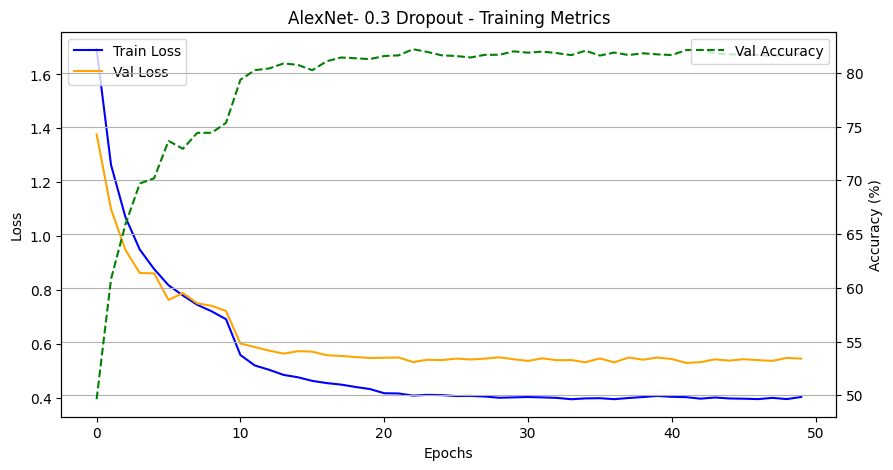

In [ ]:
# In PyTorch, compilation happens outside the model
optimizer = torch.optim.Adam(alexnet3.parameters(), lr=lr)

# CrossEntropyLoss automatically applies Softmax internally!
criterion = nn.CrossEntropyLoss()
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)
train_losses, val_losses, val_accuracies, epoch_times = train_and_evaluate(alexnet3, criterion=criterion, optimizer=optimizer,scheduler=scheduler, num_epochs=EPOCHS)
Average_Time = sum(epoch_times) / len(epoch_times)
print(f"Average time per epoch: {Average_Time:.2f} seconds")
plot_metrics(train_losses, val_losses, val_accuracies, title="AlexNet- 0.3 Dropout")

In [ ]:
torch.save(alexnet3.state_dict(), '/content/drive/MyDrive/alexnet3_cifar10.pth')

In [ ]:
# Instantiate and check parameter count
alexnet5 = ModAlexNetD(dropout_rate=0.5).to(device)
summary(alexnet5, (3, 32, 32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 48, 30, 30]           1,344
              ReLU-2           [-1, 48, 30, 30]               0
         MaxPool2d-3           [-1, 48, 28, 28]               0
            Conv2d-4           [-1, 96, 30, 30]          41,568
              ReLU-5           [-1, 96, 30, 30]               0
         MaxPool2d-6           [-1, 96, 14, 14]               0
            Conv2d-7          [-1, 192, 14, 14]         166,080
              ReLU-8          [-1, 192, 14, 14]               0
            Conv2d-9          [-1, 146, 14, 14]         252,434
             ReLU-10          [-1, 146, 14, 14]               0
        MaxPool2d-11            [-1, 146, 6, 6]               0
          Flatten-12                 [-1, 5256]               0
           Linear-13                 [-1, 1825]       9,594,025
             ReLU-14                 [-

Epoch [1/50] | Time: 10.99s | Train Loss: 1.6900 | Val Loss: 1.3501 | Val Acc: 50.84%
Epoch [2/50] | Time: 10.91s | Train Loss: 1.2801 | Val Loss: 1.1289 | Val Acc: 60.26%
Epoch [3/50] | Time: 10.82s | Train Loss: 1.1232 | Val Loss: 1.0113 | Val Acc: 64.84%
Epoch [4/50] | Time: 10.65s | Train Loss: 1.0231 | Val Loss: 0.9105 | Val Acc: 68.63%
Epoch [5/50] | Time: 10.60s | Train Loss: 0.9568 | Val Loss: 0.8865 | Val Acc: 68.95%
Epoch [6/50] | Time: 10.77s | Train Loss: 0.9009 | Val Loss: 0.8379 | Val Acc: 70.59%
Epoch [7/50] | Time: 10.83s | Train Loss: 0.8649 | Val Loss: 0.8177 | Val Acc: 71.64%
Epoch [8/50] | Time: 10.63s | Train Loss: 0.8438 | Val Loss: 0.7488 | Val Acc: 73.75%
Epoch [9/50] | Time: 10.90s | Train Loss: 0.8111 | Val Loss: 0.7525 | Val Acc: 73.99%
Epoch [10/50] | Time: 10.91s | Train Loss: 0.7903 | Val Loss: 0.7404 | Val Acc: 74.68%
Epoch [11/50] | Time: 11.06s | Train Loss: 0.6591 | Val Loss: 0.6409 | Val Acc: 78.22%
Epoch [12/50] | Time: 10.96s | Train Loss: 0.6157 | 

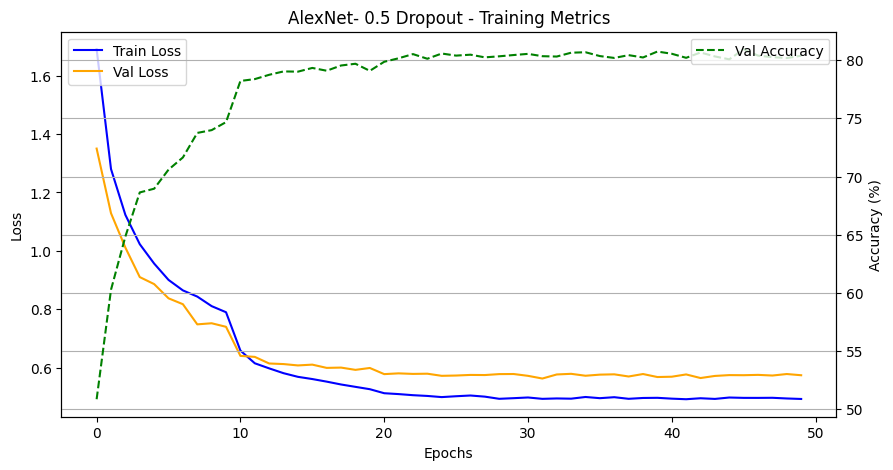

In [ ]:
# In PyTorch, compilation happens outside the model
optimizer = torch.optim.Adam(alexnet5.parameters(), lr=lr)

# CrossEntropyLoss automatically applies Softmax internally!
criterion = nn.CrossEntropyLoss()
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)
train_losses, val_losses, val_accuracies, epoch_times = train_and_evaluate(alexnet5, criterion=criterion, optimizer=optimizer,scheduler=scheduler, num_epochs=EPOCHS)
Average_Time = sum(epoch_times) / len(epoch_times)
print(f"Average time per epoch: {Average_Time:.2f} seconds")
plot_metrics(train_losses, val_losses, val_accuracies, title="AlexNet- 0.5 Dropout")

In [ ]:
torch.save(alexnet5.state_dict(), '/content/drive/MyDrive/alexnet5_cifar10.pth')

Batch Normalization

In [ ]:
# AlexNet model Part 1
class ModAlexNetBN(nn.Module):
    def __init__(self, num_classes=10, dropout_rate=0.0):
        super().__init__()
        self.features = nn.Sequential(
            # Conv1: Reduce the kernal size to more typical 5x5, reduce stride to 2, half the number of output filters
            nn.Conv2d(3, 48, kernel_size=3, stride=1, padding=0),
            nn.BatchNorm2d(48),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=1),

            # Conv2
            nn.Conv2d(48, 96, kernel_size=3, stride=1, padding=2),
            nn.BatchNorm2d(96),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),

            # Conv3
            nn.Conv2d(96, 192, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(192),
            nn.ReLU(inplace=True),

            # Conv5
            nn.Conv2d(192, 146, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(146),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2)
        )

        # 2. Classifier (Dense/Linear Layers)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            # Assuming standard AlexNet input image size of 227x227
            # After pooling, spatial dimensions are 6x6.
            # 146 channels * 6 * 6 = 3650
            nn.Linear(146 * 6 * 6, 1825),
            nn.ReLU(inplace=True),

            nn.Linear(1825, 500),
            nn.ReLU(inplace=True),

            # Output layer (No Softmax here!)
            nn.Linear(500, num_classes)
        )

        # 3. Apply He Normal (Kaiming) Initialization
        self._initialize_weights()

    # 4. Explicitly define the forward pass
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.constant_(m.bias, 0)

# Instantiate and check parameter count
alexnetB = ModAlexNetBN(dropout_rate=0.0).to(device)
summary(alexnetB, (3, 32, 32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 48, 30, 30]           1,344
       BatchNorm2d-2           [-1, 48, 30, 30]              96
              ReLU-3           [-1, 48, 30, 30]               0
         MaxPool2d-4           [-1, 48, 28, 28]               0
            Conv2d-5           [-1, 96, 30, 30]          41,568
       BatchNorm2d-6           [-1, 96, 30, 30]             192
              ReLU-7           [-1, 96, 30, 30]               0
         MaxPool2d-8           [-1, 96, 14, 14]               0
            Conv2d-9          [-1, 192, 14, 14]         166,080
      BatchNorm2d-10          [-1, 192, 14, 14]             384
             ReLU-11          [-1, 192, 14, 14]               0
           Conv2d-12          [-1, 146, 14, 14]         252,434
      BatchNorm2d-13          [-1, 146, 14, 14]             292
             ReLU-14          [-1, 146,

Epoch [1/50] | Time: 10.84s | Train Loss: 1.4962 | Val Loss: 1.3326 | Val Acc: 51.64%
Epoch [2/50] | Time: 10.44s | Train Loss: 1.1084 | Val Loss: 1.0222 | Val Acc: 63.74%
Epoch [3/50] | Time: 10.27s | Train Loss: 0.9434 | Val Loss: 0.9038 | Val Acc: 68.32%
Epoch [4/50] | Time: 10.37s | Train Loss: 0.8164 | Val Loss: 0.8729 | Val Acc: 69.08%
Epoch [5/50] | Time: 10.21s | Train Loss: 0.7370 | Val Loss: 0.7213 | Val Acc: 74.36%
Epoch [6/50] | Time: 10.61s | Train Loss: 0.6768 | Val Loss: 0.7038 | Val Acc: 75.38%
Epoch [7/50] | Time: 10.36s | Train Loss: 0.6257 | Val Loss: 0.6369 | Val Acc: 77.88%
Epoch [8/50] | Time: 10.95s | Train Loss: 0.5785 | Val Loss: 0.6299 | Val Acc: 78.17%
Epoch [9/50] | Time: 10.60s | Train Loss: 0.5431 | Val Loss: 0.5812 | Val Acc: 80.10%
Epoch [10/50] | Time: 10.30s | Train Loss: 0.5141 | Val Loss: 0.5661 | Val Acc: 80.77%
Epoch [11/50] | Time: 10.28s | Train Loss: 0.3917 | Val Loss: 0.4817 | Val Acc: 83.11%
Epoch [12/50] | Time: 10.70s | Train Loss: 0.3652 | 

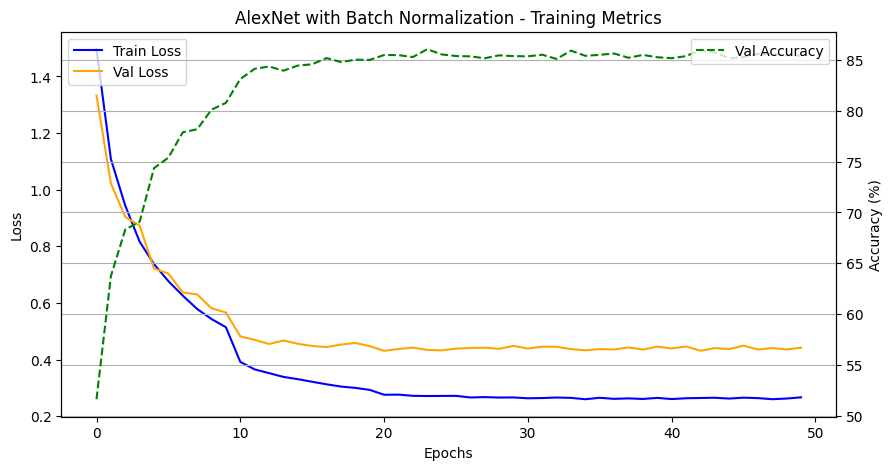

In [ ]:
# In PyTorch, compilation happens outside the model
optimizer = torch.optim.Adam(alexnetB.parameters(), lr=lr)

# CrossEntropyLoss automatically applies Softmax internally!
criterion = nn.CrossEntropyLoss()
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)
train_losses, val_losses, val_accuracies, epoch_times = train_and_evaluate(alexnetB, criterion=criterion, optimizer=optimizer,scheduler=scheduler, num_epochs=EPOCHS)
Average_Time = sum(epoch_times) / len(epoch_times)
print(f"Average time per epoch: {Average_Time:.2f} seconds")
plot_metrics(train_losses, val_losses, val_accuracies, title="AlexNet with Batch Normalization")

In [ ]:
torch.save(alexnetB.state_dict(), '/content/drive/MyDrive/alexnetB_cifar10.pth')

Modified VGGNet

In [ ]:
class AdaptedVGG11(nn.Module):
    def __init__(self, num_classes=10, dropout_rate=0.0):
        super(AdaptedVGG11, self).__init__()
        # VGG-11 configuration: [64, 'M', 128, 'M', 256, 256, 'M', 512, 512, 'M', 512, 512, 'M']
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
            # output is 512 x 1 x 1
        )
        self.classifier = nn.Sequential(
            nn.Dropout(p=dropout_rate),
            nn.Linear(512 * 1 * 1, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_rate),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

vggnet = AdaptedVGG11(dropout_rate=0.0).to(device)
summary(vggnet, (3, 32, 32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 32, 32]           1,792
              ReLU-2           [-1, 64, 32, 32]               0
         MaxPool2d-3           [-1, 64, 16, 16]               0
            Conv2d-4          [-1, 128, 16, 16]          73,856
              ReLU-5          [-1, 128, 16, 16]               0
         MaxPool2d-6            [-1, 128, 8, 8]               0
            Conv2d-7            [-1, 256, 8, 8]         295,168
              ReLU-8            [-1, 256, 8, 8]               0
            Conv2d-9            [-1, 256, 8, 8]         590,080
             ReLU-10            [-1, 256, 8, 8]               0
        MaxPool2d-11            [-1, 256, 4, 4]               0
           Conv2d-12            [-1, 512, 4, 4]       1,180,160
             ReLU-13            [-1, 512, 4, 4]               0
           Conv2d-14            [-1, 51

Epoch [1/50] | Time: 10.48s | Train Loss: 1.8913 | Val Loss: 1.6447 | Val Acc: 35.56%
Epoch [2/50] | Time: 10.31s | Train Loss: 1.5389 | Val Loss: 1.3606 | Val Acc: 51.31%
Epoch [3/50] | Time: 10.54s | Train Loss: 1.2948 | Val Loss: 1.2616 | Val Acc: 54.66%
Epoch [4/50] | Time: 10.82s | Train Loss: 1.1240 | Val Loss: 1.0793 | Val Acc: 62.12%
Epoch [5/50] | Time: 10.78s | Train Loss: 1.0256 | Val Loss: 1.0130 | Val Acc: 64.68%
Epoch [6/50] | Time: 11.17s | Train Loss: 0.9346 | Val Loss: 0.9190 | Val Acc: 67.42%
Epoch [7/50] | Time: 10.43s | Train Loss: 0.8809 | Val Loss: 0.8736 | Val Acc: 70.07%
Epoch [8/50] | Time: 10.30s | Train Loss: 0.8245 | Val Loss: 0.8330 | Val Acc: 70.67%
Epoch [9/50] | Time: 10.26s | Train Loss: 0.7705 | Val Loss: 0.7870 | Val Acc: 73.39%
Epoch [10/50] | Time: 10.48s | Train Loss: 0.7367 | Val Loss: 0.7500 | Val Acc: 74.88%
Epoch [11/50] | Time: 10.48s | Train Loss: 0.5931 | Val Loss: 0.6723 | Val Acc: 77.05%
Epoch [12/50] | Time: 10.61s | Train Loss: 0.5545 | 

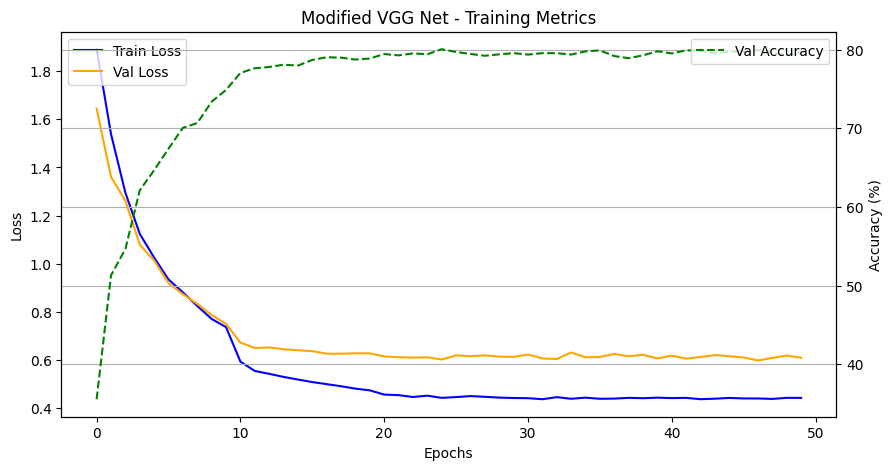

In [ ]:
# In PyTorch, compilation happens outside the model
optimizer = torch.optim.Adam(vggnet.parameters(), lr=lr)

# CrossEntropyLoss automatically applies Softmax internally!
criterion = nn.CrossEntropyLoss()
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)
train_losses, val_losses, val_accuracies, epoch_times = train_and_evaluate(vggnet, criterion=criterion, optimizer=optimizer,scheduler=scheduler, num_epochs=EPOCHS)
Average_Time = sum(epoch_times) / len(epoch_times)
print(f"Average time per epoch: {Average_Time:.2f} seconds")
plot_metrics(train_losses, val_losses, val_accuracies, title="Modified VGG Net")

In [ ]:
torch.save(vggnet.state_dict(), '/content/drive/MyDrive/vggnet_cifar10.pth')

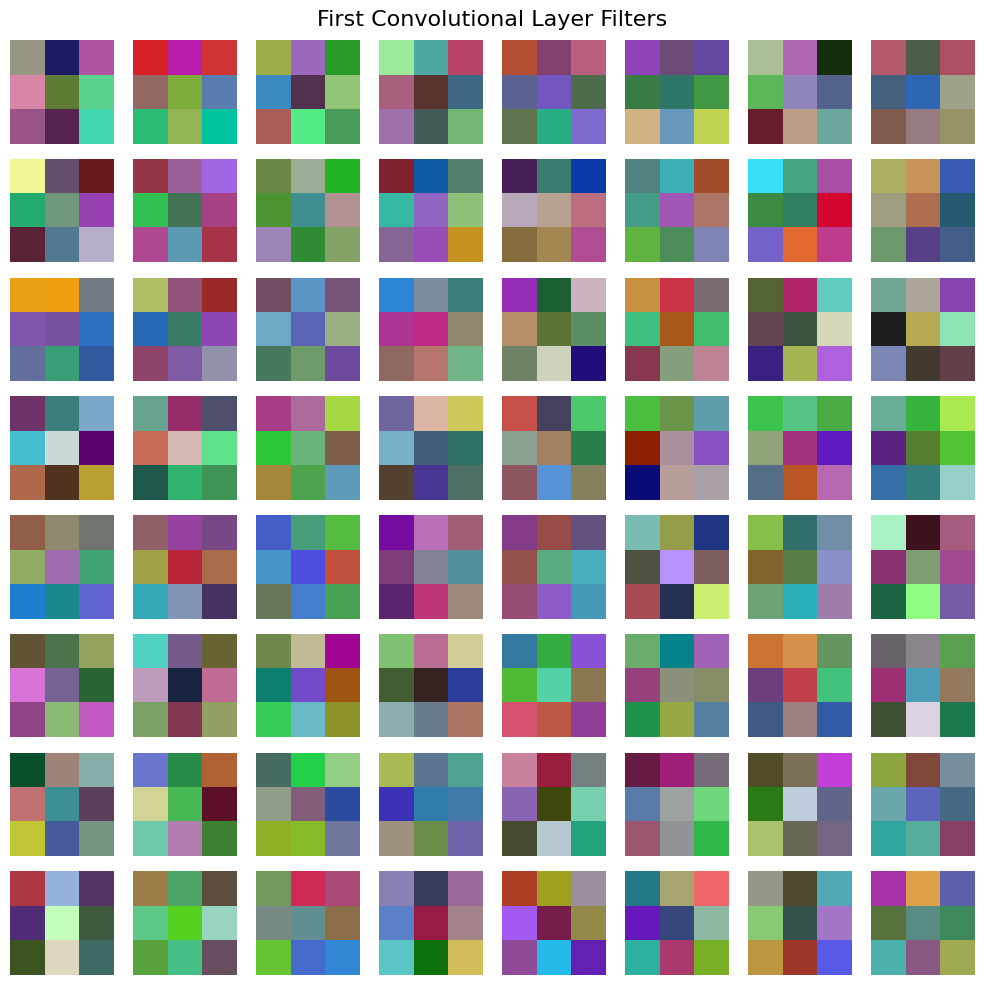

Generating predictions for confusion matrix...


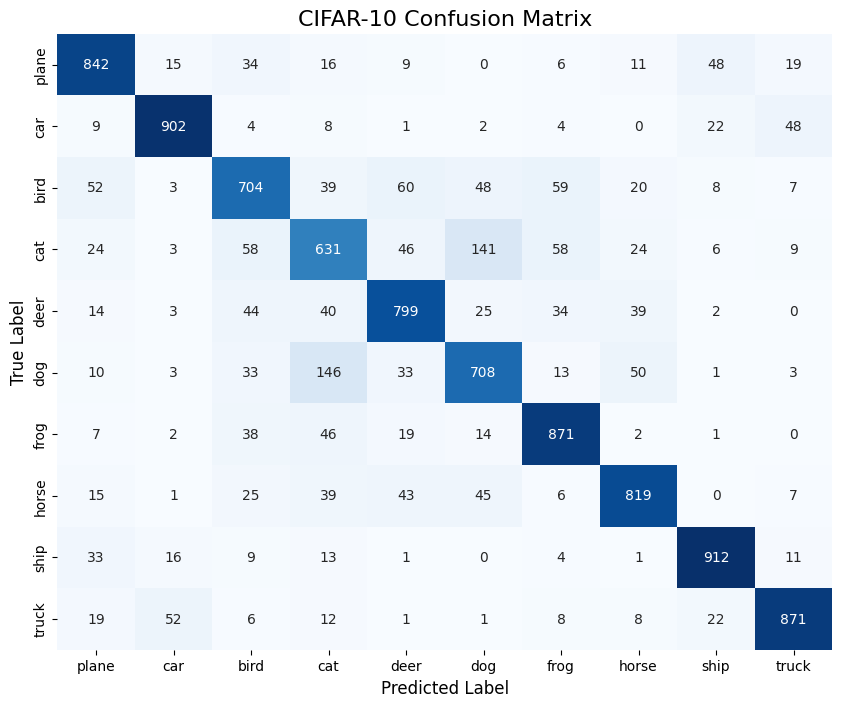

In [ ]:
visualize_first_layer_filters(vggnet)
plot_confusion_matrix(vggnet, testloader, classes, device)

Epoch [1/50] | Time: 10.64s | Train Loss: 2.0178 | Val Loss: 1.7837 | Val Acc: 29.82%
Epoch [2/50] | Time: 11.49s | Train Loss: 1.6271 | Val Loss: 1.4911 | Val Acc: 43.41%
Epoch [3/50] | Time: 10.37s | Train Loss: 1.3963 | Val Loss: 1.3259 | Val Acc: 51.29%
Epoch [4/50] | Time: 10.79s | Train Loss: 1.2537 | Val Loss: 1.1387 | Val Acc: 58.57%
Epoch [5/50] | Time: 10.81s | Train Loss: 1.1501 | Val Loss: 1.1124 | Val Acc: 60.46%
Epoch [6/50] | Time: 10.51s | Train Loss: 1.0792 | Val Loss: 1.1314 | Val Acc: 60.87%
Epoch [7/50] | Time: 10.56s | Train Loss: 1.0272 | Val Loss: 0.9794 | Val Acc: 66.64%
Epoch [8/50] | Time: 10.40s | Train Loss: 0.9688 | Val Loss: 0.9747 | Val Acc: 65.92%
Epoch [9/50] | Time: 10.20s | Train Loss: 0.9300 | Val Loss: 0.8992 | Val Acc: 68.88%
Epoch [10/50] | Time: 10.65s | Train Loss: 0.9046 | Val Loss: 0.9068 | Val Acc: 69.10%
Epoch [11/50] | Time: 10.42s | Train Loss: 0.7576 | Val Loss: 0.7660 | Val Acc: 73.31%
Epoch [12/50] | Time: 10.54s | Train Loss: 0.7315 | 

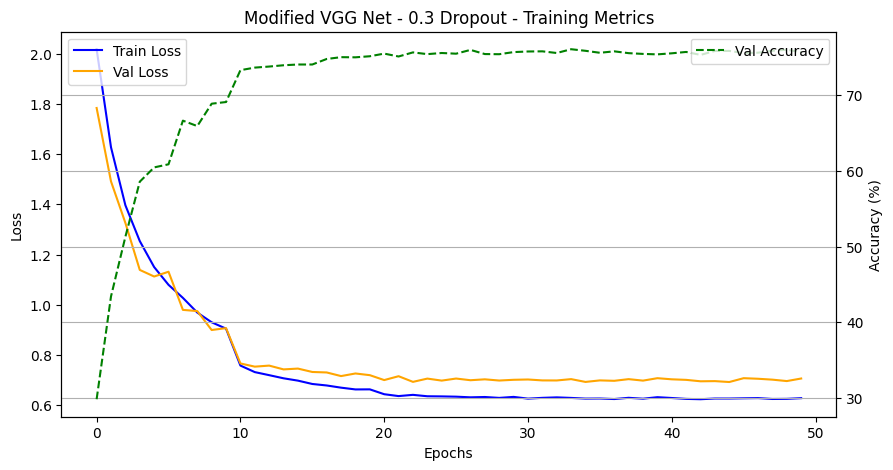

In [ ]:
vggnet3 = AdaptedVGG11(dropout_rate=0.3).to(device)
# In PyTorch, compilation happens outside the model
optimizer = torch.optim.Adam(vggnet3.parameters(), lr=lr)

# CrossEntropyLoss automatically applies Softmax internally!
criterion = nn.CrossEntropyLoss()
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)
train_losses, val_losses, val_accuracies, epoch_times = train_and_evaluate(vggnet3, criterion=criterion, optimizer=optimizer,scheduler=scheduler, num_epochs=EPOCHS)
Average_Time = sum(epoch_times) / len(epoch_times)
print(f"Average time per epoch: {Average_Time:.2f} seconds")
plot_metrics(train_losses, val_losses, val_accuracies, title="Modified VGG Net - 0.3 Dropout")

In [ ]:
torch.save(vggnet3.state_dict(), '/content/drive/MyDrive/vggnet3_cifar10.pth')

Epoch [1/50] | Time: 10.56s | Train Loss: 1.9808 | Val Loss: 1.7436 | Val Acc: 30.55%
Epoch [2/50] | Time: 10.82s | Train Loss: 1.6621 | Val Loss: 1.5350 | Val Acc: 40.95%
Epoch [3/50] | Time: 10.71s | Train Loss: 1.4265 | Val Loss: 1.2999 | Val Acc: 51.29%
Epoch [4/50] | Time: 10.55s | Train Loss: 1.2846 | Val Loss: 1.1516 | Val Acc: 58.87%
Epoch [5/50] | Time: 10.55s | Train Loss: 1.1605 | Val Loss: 1.0460 | Val Acc: 62.40%
Epoch [6/50] | Time: 10.92s | Train Loss: 1.0523 | Val Loss: 1.0100 | Val Acc: 65.36%
Epoch [7/50] | Time: 10.41s | Train Loss: 0.9862 | Val Loss: 0.9749 | Val Acc: 66.26%
Epoch [8/50] | Time: 10.53s | Train Loss: 0.9274 | Val Loss: 0.8833 | Val Acc: 69.97%
Epoch [9/50] | Time: 11.39s | Train Loss: 0.9004 | Val Loss: 0.8447 | Val Acc: 70.99%
Epoch [10/50] | Time: 10.55s | Train Loss: 0.8588 | Val Loss: 0.9085 | Val Acc: 68.83%
Epoch [11/50] | Time: 10.52s | Train Loss: 0.7246 | Val Loss: 0.7319 | Val Acc: 74.72%
Epoch [12/50] | Time: 10.94s | Train Loss: 0.6899 | 

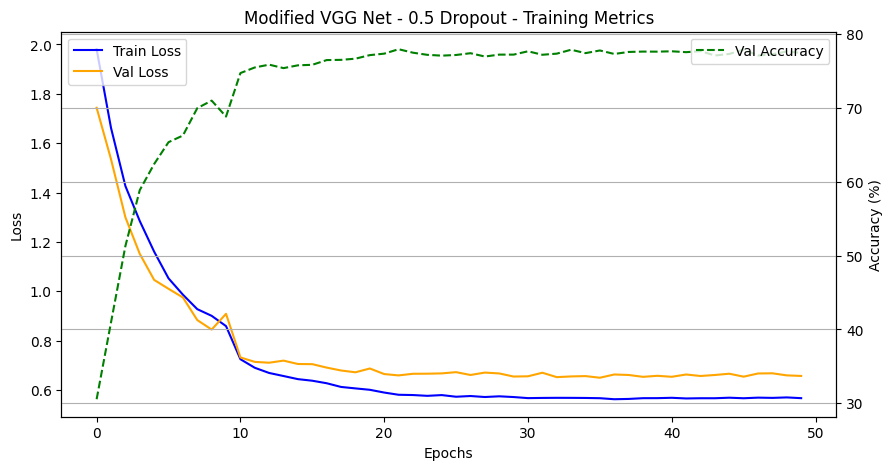

In [ ]:
vggnet5 = AdaptedVGG11(dropout_rate=0.5).to(device)
# In PyTorch, compilation happens outside the model
optimizer = torch.optim.Adam(vggnet5.parameters(), lr=lr)

# CrossEntropyLoss automatically applies Softmax internally!
criterion = nn.CrossEntropyLoss()
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)
train_losses, val_losses, val_accuracies, epoch_times = train_and_evaluate(vggnet5, criterion=criterion, optimizer=optimizer,scheduler=scheduler, num_epochs=EPOCHS)
Average_Time = sum(epoch_times) / len(epoch_times)
print(f"Average time per epoch: {Average_Time:.2f} seconds")
plot_metrics(train_losses, val_losses, val_accuracies, title="Modified VGG Net - 0.5 Dropout")

In [ ]:
torch.save(vggnet5.state_dict(), '/content/drive/MyDrive/vggnet5_cifar10.pth')

In [ ]:
class AdaptedVGG11_BN(nn.Module):
    def __init__(self, num_classes=10, dropout_rate=0.0):
        super(AdaptedVGG11_BN, self).__init__()

        # VGG-11 Configuration with BatchNorm2d added after every Conv2d
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
            # Output spatial dimensions: 512 x 1 x 1
        )

        self.classifier = nn.Sequential(
            nn.Dropout(p=dropout_rate),
            nn.Linear(512 * 1 * 1, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_rate),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

# Test the model and check parameter counts
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vggnetBN = AdaptedVGG11_BN(dropout_rate=0.0).to(device)
summary(vggnetBN, (3, 32, 32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 32, 32]           1,792
       BatchNorm2d-2           [-1, 64, 32, 32]             128
              ReLU-3           [-1, 64, 32, 32]               0
         MaxPool2d-4           [-1, 64, 16, 16]               0
            Conv2d-5          [-1, 128, 16, 16]          73,856
       BatchNorm2d-6          [-1, 128, 16, 16]             256
              ReLU-7          [-1, 128, 16, 16]               0
         MaxPool2d-8            [-1, 128, 8, 8]               0
            Conv2d-9            [-1, 256, 8, 8]         295,168
      BatchNorm2d-10            [-1, 256, 8, 8]             512
             ReLU-11            [-1, 256, 8, 8]               0
           Conv2d-12            [-1, 256, 8, 8]         590,080
      BatchNorm2d-13            [-1, 256, 8, 8]             512
             ReLU-14            [-1, 25

In [ ]:
torch.save(vggnetBN.state_dict(), '/content/drive/MyDrive/vggnet_bn_cifar10.pth')

Epoch [1/50] | Time: 10.70s | Train Loss: 1.6057 | Val Loss: 1.3127 | Val Acc: 49.85%
Epoch [2/50] | Time: 10.50s | Train Loss: 1.1684 | Val Loss: 1.0870 | Val Acc: 61.18%
Epoch [3/50] | Time: 10.41s | Train Loss: 0.9700 | Val Loss: 0.9312 | Val Acc: 66.77%
Epoch [4/50] | Time: 10.46s | Train Loss: 0.8480 | Val Loss: 0.8224 | Val Acc: 71.68%
Epoch [5/50] | Time: 10.54s | Train Loss: 0.7387 | Val Loss: 0.7315 | Val Acc: 74.42%
Epoch [6/50] | Time: 11.56s | Train Loss: 0.6762 | Val Loss: 0.7025 | Val Acc: 76.19%
Epoch [7/50] | Time: 10.24s | Train Loss: 0.6110 | Val Loss: 0.6311 | Val Acc: 78.14%
Epoch [8/50] | Time: 10.31s | Train Loss: 0.5643 | Val Loss: 0.6476 | Val Acc: 77.63%
Epoch [9/50] | Time: 10.45s | Train Loss: 0.5236 | Val Loss: 0.5574 | Val Acc: 81.44%
Epoch [10/50] | Time: 10.41s | Train Loss: 0.4852 | Val Loss: 0.5500 | Val Acc: 81.43%
Epoch [11/50] | Time: 10.46s | Train Loss: 0.3663 | Val Loss: 0.4249 | Val Acc: 85.43%
Epoch [12/50] | Time: 10.68s | Train Loss: 0.3278 | 

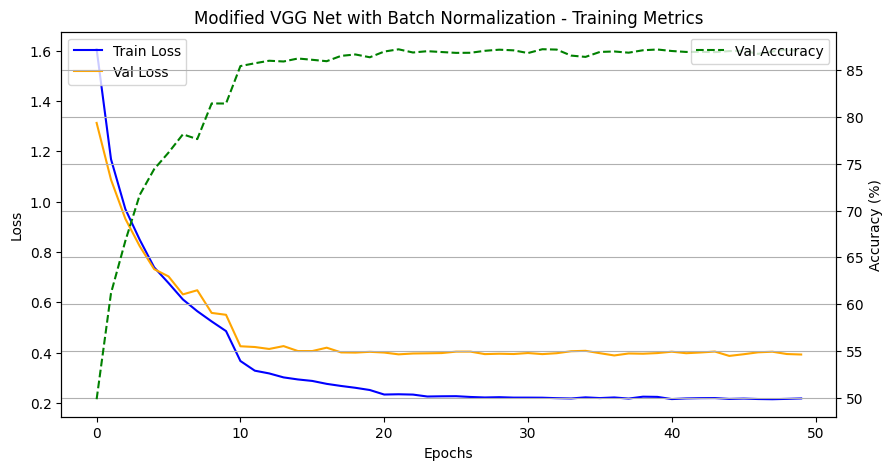

In [ ]:
# In PyTorch, compilation happens outside the model
optimizer = torch.optim.Adam(vggnetBN.parameters(), lr=lr)

# CrossEntropyLoss automatically applies Softmax internally!
criterion = nn.CrossEntropyLoss()
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)
train_losses, val_losses, val_accuracies, epoch_times = train_and_evaluate(vggnetBN, criterion=criterion, optimizer=optimizer,scheduler=scheduler, num_epochs=EPOCHS)
Average_Time = sum(epoch_times) / len(epoch_times)
print(f"Average time per epoch: {Average_Time:.2f} seconds")
plot_metrics(train_losses, val_losses, val_accuracies, title="Modified VGG Net with Batch Normalization")

ResNet-11 vs. ResNet-18 on CIFAR-10

In [ ]:
class ResBlock(nn.Module):

  expansion = 1
  def __init__(self, in_channels, out_channels, stride=1):
    super(ResBlock, self).__init__()
    self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1)
    self.bn1 = nn.BatchNorm2d(out_channels)
    self.relu = nn.ReLU(inplace=True)
    self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1)
    self.bn2 = nn.BatchNorm2d(out_channels)

    self.shortcut = nn.Sequential()
    if stride != 1 or in_channels != self.expansion * out_channels:
        self.shortcut = nn.Sequential(
            nn.Conv2d(in_channels, self.expansion * out_channels, kernel_size=1, stride=stride, bias=False),
            nn.BatchNorm2d(self.expansion * out_channels)
        )

  def forward(self, x):
    identity = x # Store the original input for the shortcut connection
    out = self.conv1(x)
    out = self.bn1(out)
    out = self.relu(out)
    out = self.conv2(out)
    out = self.bn2(out)

    out += self.shortcut(identity) # Apply shortcut to the original input
    out = self.relu(out)
    return out

class ResNet18(nn.Module):
  def __init__(self, image_channels, num_classes, dropout_rate=0.0):

    super(ResNet18, self).__init__()
    self.in_channels = 64
    self.conv1 = nn.Conv2d(image_channels, 64, kernel_size=3, stride=2, padding=3)
    self.bn1 = nn.BatchNorm2d(64)
    self.relu = nn.ReLU(inplace=True)

    self.layer1 = self._make_layer(64, 2, stride=1)
    self.layer2 = self._make_layer(128, 2, stride=2)
    self.layer3 = self._make_layer(256, 2, stride=2)
    self.layer4 = self._make_layer(512, 2, stride=2)

    self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
    self.fc = nn.Linear(512, num_classes)
    self.dropout = nn.Dropout(dropout_rate)

  def _make_layer(self, out_channels, num_blocks, stride):
    """
    Dynamically generates the blocks for a specific stage.
    """
    strides = [stride] + [1] * (num_blocks - 1)
    layers = []
    for s in strides:
        layers.append(ResBlock(self.in_channels, out_channels, s))
        self.in_channels = out_channels * ResBlock.expansion
    return nn.Sequential(*layers)

  def forward(self, x):

    x = self.conv1(x)
    x = self.bn1(x)
    x = self.relu(x)

    x = self.layer1(x)
    x = self.layer2(x)
    x = self.layer3(x)
    x = self.layer4(x)

    x = self.avgpool(x)
    x = x.view(x.shape[0], -1)
    x = self.dropout(x)
    x = self.fc(x)

    return x


class ResNet11(nn.Module):
  def __init__(self, image_channels, num_classes, dropout_rate=0.0):

    super(ResNet11, self).__init__()
    self.in_channels = 64
    self.conv1 = nn.Conv2d(image_channels, 64, kernel_size=3, stride=2, padding=3)
    self.bn1 = nn.BatchNorm2d(64)
    self.relu = nn.ReLU(inplace=True)

    self.layer1 = self._make_layer(64, 2, stride=1)
    self.layer2 = self._make_layer(128, 2, stride=2)

    self.conv2  = nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1)
    self.bn2 = nn.BatchNorm2d(256)
    self.relu2 = nn.ReLU(inplace=True)

    self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
    self.fc = nn.Linear(256, num_classes)
    self.dropout = nn.Dropout(dropout_rate)

  def _make_layer(self, out_channels, num_blocks, stride):
    """
    Dynamically generates the blocks for a specific stage.
    """
    strides = [stride] + [1] * (num_blocks - 1)
    layers = []
    for s in strides:
        layers.append(ResBlock(self.in_channels, out_channels, s))
        self.in_channels = out_channels * ResBlock.expansion
    return nn.Sequential(*layers)

  def forward(self, x):

    x = self.conv1(x)
    x = self.bn1(x)
    x = self.relu(x)

    x = self.layer1(x)
    x = self.layer2(x)

    x = self.conv2(x)
    x = self.bn2(x)
    x = self.relu2(x)

    x = self.avgpool(x)
    x = x.view(x.shape[0], -1)
    x = self.dropout(x)
    x = self.fc(x)

    return x




----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 18, 18]           1,792
       BatchNorm2d-2           [-1, 64, 18, 18]             128
              ReLU-3           [-1, 64, 18, 18]               0
            Conv2d-4           [-1, 64, 18, 18]          36,928
       BatchNorm2d-5           [-1, 64, 18, 18]             128
              ReLU-6           [-1, 64, 18, 18]               0
            Conv2d-7           [-1, 64, 18, 18]          36,928
       BatchNorm2d-8           [-1, 64, 18, 18]             128
              ReLU-9           [-1, 64, 18, 18]               0
         ResBlock-10           [-1, 64, 18, 18]               0
           Conv2d-11           [-1, 64, 18, 18]          36,928
      BatchNorm2d-12           [-1, 64, 18, 18]             128
             ReLU-13           [-1, 64, 18, 18]               0
           Conv2d-14           [-1, 64,

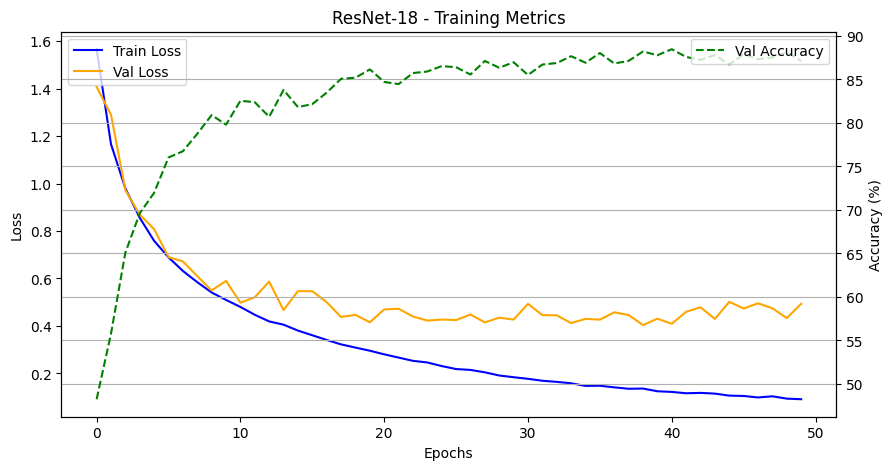

In [ ]:
resnet18 = ResNet18(3, 10, dropout_rate=0.0).to(device)
summary(resnet18, (3, 32, 32))
optimizer = torch.optim.Adam(resnet18.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()
lr_scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)
train_losses, val_losses, val_accuracies, epoch_times = train_and_evaluate(resnet18, criterion=criterion, optimizer=optimizer,scheduler=scheduler, num_epochs=EPOCHS)
Average_Time = sum(epoch_times) / len(epoch_times)
print(f"Average time per epoch: {Average_Time:.2f} seconds")
plot_metrics(train_losses, val_losses, val_accuracies, title="ResNet-18")

Generating predictions for confusion matrix...


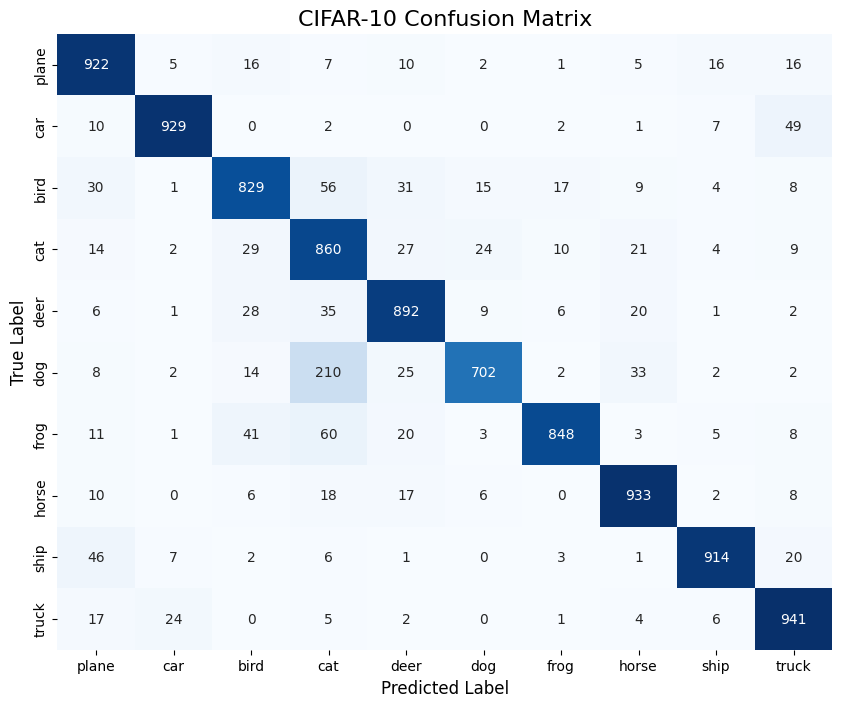

In [ ]:
plot_confusion_matrix(resnet18, testloader, classes, device)

In [ ]:
torch.save(resnet18.state_dict(), '/content/drive/MyDrive/resnet18_cifar10.pth')

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 18, 18]           1,792
       BatchNorm2d-2           [-1, 64, 18, 18]             128
              ReLU-3           [-1, 64, 18, 18]               0
            Conv2d-4           [-1, 64, 18, 18]          36,928
       BatchNorm2d-5           [-1, 64, 18, 18]             128
              ReLU-6           [-1, 64, 18, 18]               0
            Conv2d-7           [-1, 64, 18, 18]          36,928
       BatchNorm2d-8           [-1, 64, 18, 18]             128
              ReLU-9           [-1, 64, 18, 18]               0
         ResBlock-10           [-1, 64, 18, 18]               0
           Conv2d-11           [-1, 64, 18, 18]          36,928
      BatchNorm2d-12           [-1, 64, 18, 18]             128
             ReLU-13           [-1, 64, 18, 18]               0
           Conv2d-14           [-1, 64,

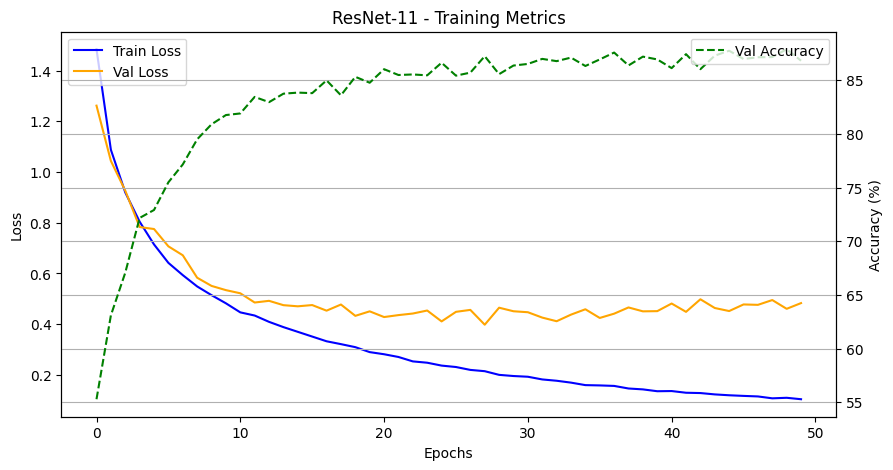

In [ ]:
resnet11 = ResNet11(3, 10, dropout_rate=0.0).to(device)
summary(resnet11, (3, 32, 32))
optimizer = torch.optim.Adam(resnet11.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()
lr_scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)
train_losses, val_losses, val_accuracies, epoch_times = train_and_evaluate(resnet11, criterion=criterion, optimizer=optimizer,scheduler=scheduler, num_epochs=EPOCHS)
Average_Time = sum(epoch_times) / len(epoch_times)
print(f"Average time per epoch: {Average_Time:.2f} seconds")
plot_metrics(train_losses, val_losses, val_accuracies, title="ResNet-11")

Generating predictions for confusion matrix...


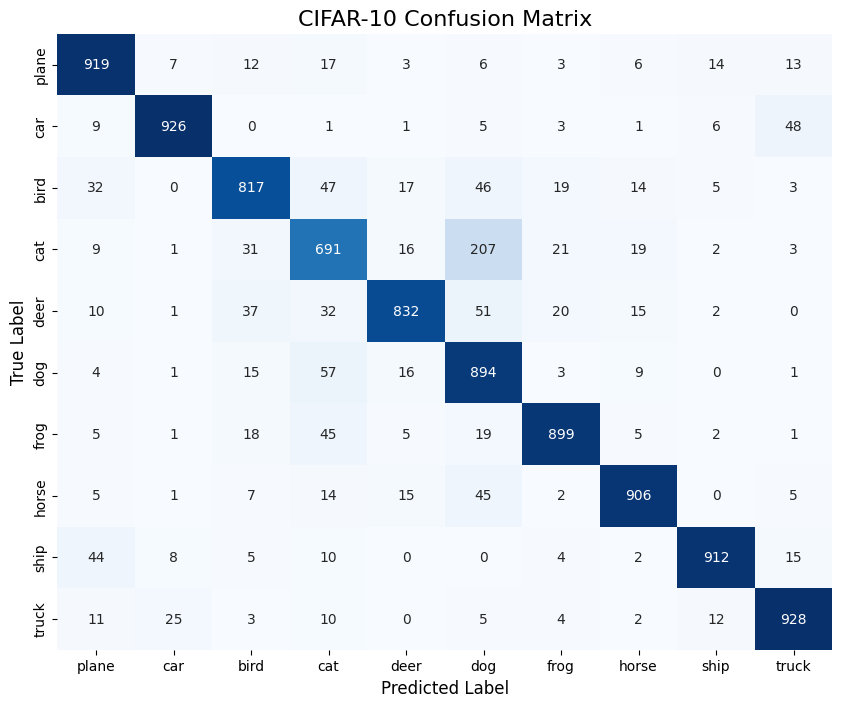

In [ ]:
plot_confusion_matrix(resnet11, testloader, classes, device)

In [ ]:
torch.save(resnet11.state_dict(), '/content/drive/MyDrive/resnet11_cifar10.pth')

In [ ]:

class ResNet34(nn.Module):
  def __init__(self, image_channels, num_classes, dropout_rate=0.0):

    super(ResNet34, self).__init__()
    self.in_channels = 64
    self.conv1 = nn.Conv2d(image_channels, 64, kernel_size=3, stride=2, padding=3)
    self.bn1 = nn.BatchNorm2d(64)
    self.relu = nn.ReLU(inplace=True)

    self.layer1 = self._make_layer(64, num_blocks=3, stride=1)
    self.layer2 = self._make_layer(128, num_blocks=4, stride=2)
    self.layer3 = self._make_layer(256, num_blocks=6, stride=2)
    self.layer4 = self._make_layer(512, num_blocks=3, stride=2)

    self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
    self.dropout = nn.Dropout(p=dropout_rate)
    # ResNet-34 ends with 512 channels
    self.fc = nn.Linear(512 * ResBlock.expansion, num_classes)

  def _make_layer(self, out_channels, num_blocks, stride):
    """
    Dynamically generates the blocks for a specific stage.
    """
    strides = [stride] + [1] * (num_blocks - 1)
    layers = []
    for s in strides:
        layers.append(ResBlock(self.in_channels, out_channels, s))
        self.in_channels = out_channels * ResBlock.expansion
    return nn.Sequential(*layers)

  def forward(self, x):

    x = self.conv1(x)
    x = self.bn1(x)
    x = self.relu(x)

    x = self.layer1(x)
    x = self.layer2(x)
    x = self.layer3(x)
    x = self.layer4(x)

    # Classification Head
    x = self.avgpool(x)
    x = torch.flatten(x, 1)
    x = self.dropout(x)
    x = self.fc(x)

    return x




----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 18, 18]           1,792
       BatchNorm2d-2           [-1, 64, 18, 18]             128
              ReLU-3           [-1, 64, 18, 18]               0
            Conv2d-4           [-1, 64, 18, 18]          36,928
       BatchNorm2d-5           [-1, 64, 18, 18]             128
              ReLU-6           [-1, 64, 18, 18]               0
            Conv2d-7           [-1, 64, 18, 18]          36,928
       BatchNorm2d-8           [-1, 64, 18, 18]             128
              ReLU-9           [-1, 64, 18, 18]               0
         ResBlock-10           [-1, 64, 18, 18]               0
           Conv2d-11           [-1, 64, 18, 18]          36,928
      BatchNorm2d-12           [-1, 64, 18, 18]             128
             ReLU-13           [-1, 64, 18, 18]               0
           Conv2d-14           [-1, 64,

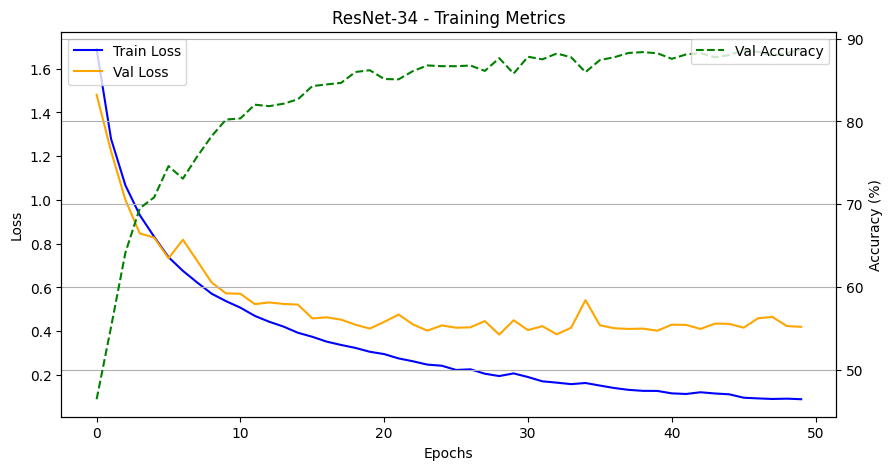

In [ ]:
resnet34 = ResNet34(3, 10, dropout_rate=0.0).to(device)
summary(resnet34, (3, 32, 32))
optimizer = torch.optim.Adam(resnet34.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()
lr_scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)
train_losses, val_losses, val_accuracies, epoch_times = train_and_evaluate(resnet34, criterion=criterion, optimizer=optimizer,scheduler=scheduler, num_epochs=EPOCHS)
Average_Time = sum(epoch_times) / len(epoch_times)
print(f"Average time per epoch: {Average_Time:.2f} seconds")
plot_metrics(train_losses, val_losses, val_accuracies, title="ResNet-34")

In [ ]:
torch.save(resnet34.state_dict(), '/content/drive/MyDrive/resnet34_cifar10.pth')